# Dataset custom

In [1]:
# data_option = "dataset1"
# data_option = "dataset2"
data_option = "custom"

## Section 1. Initial setup

In [2]:
from speciesot import configure_platform, Config, Data, SpeciesOT

In [3]:
configure_platform()
# configure_platform("gpu")
# configure_platform("cpu")

JAX is configured to use: METAL


### Parameters

In [4]:
if data_option == "custom":
    mask_option = "one_time_point_data"
    threshold = 1.4
    threshold_surer = 2.5
    high_epsilon = 0.01

elif data_option == "dataset2":
    mask_option = "one_time_point_data"
    threshold = 1.4
    threshold_surer = 2.5
    high_epsilon = 0.1

elif data_option == "dataset1":
    mask_option = "time_series_data"
    threshold = 3.0
    threshold_surer = 3.5
    high_epsilon = 0.01

else:
    print("Check data_option.")

In [5]:
iterations = 1000
threshold_eps = 1e-4
low_epsilon = 0.0
threshold_tol = 3.0

In [6]:
if data_option == "dataset1":
    species = ["human", "macaque", "mouse"]
    species_pairs = []  # overwrite later
    species_labels = ["Human", "Macaque", "Mouse"]

elif data_option == "dataset2":
    species = ["human", "chimpanzee", "gorilla", "orangutan", "macaque", "mouse"]
    species_pairs = []  # overwrite later
    species_labels = [
        "Human_iPSC(AK02)",
        "Chimp_iPSC(AK02)",
        "Gorilla_iPSC(AITS)",
        "Orang_iPSC(AITS)",
        "Macaque_ESC(AITS)",
        "Mouse_EpiLC",
    ]

elif data_option == "custom":
    species = ["animal1", "animal2", "animal3"]
    species_pairs = []  # overwrite later
    species_labels = ["Animal1", "Animal2", "Animal3"]

### Set constants

- `mouse_option` : When `data_option = “fujiwara”`, `“mESC#1”` and `“mESC#2”` disappear (`‘drop’`). Only `“drop”` exists.

- `gene_option` : Whether to restrict the analysis to only genes common to all species (`“intersection”`) or not (`“distinct”`)

- `threshold_option` : Whether the threshold for masking in the “preprocessing” process should be automatically adjusted (`"auto"`) or fixed to the value of `threshold_surer` (`"manual"`)

- `metric_option` : Whether the distance matrix between genes is calculated using Euclidean distance (`"euclidean"`) or after weighting the genes (`"weighted"`)

- `dismat_option` : Whether to use principal component analyzed data (`"pca"`) or original data (`"original"`)

- `gwot_option` : Whether to use the smallest hyperparameter epsilon (`"min"`) or only the initial value (`"fixed"`) when performing gromov-wasserstein ot calculations

In [7]:
if data_option == "custom":
    config = Config(
        data_option="custom",
        mouse_option="drop",
        gene_option="distinct",
        threshold_option="auto",
        metric_option="euclidean",
        dismat_option="original",
        gwot_option="fixed",
        mask_option=mask_option,
        iterations=iterations,
        threshold_eps=threshold_eps,
        low_epsilon=low_epsilon,
        high_epsilon=high_epsilon,
        threshold_tol=threshold_tol,
        threshold=threshold,
        threshold_surer=threshold_surer,
        species=species,
        species_pairs=species_pairs,
        species_labels=species_labels,
    )
elif data_option == "dataset2":
    config = Config(
        "dataset2",
        "drop",
        "distinct",
        "auto",
        "euclidean",
        "original",
        "fixed",
        mask_option,
        iterations,
        threshold_eps,
        low_epsilon,
        high_epsilon,
        threshold_tol,
        threshold,
        threshold_surer,
        species=species,
        species_pairs=species_pairs,
        species_labels=species_labels,
    )
elif data_option == "dataset1":
    config = Config(
        "dataset1",
        "drop",
        "distinct",
        "auto",
        "euclidean",
        "original",
        "fixed",
        mask_option,
        iterations,
        threshold_eps,
        low_epsilon,
        high_epsilon,
        threshold_tol,
        threshold,
        threshold_surer,
        species=species,
        species_pairs=species_pairs,
        species_labels=species_labels,
    )

## Section 2. Data preparation

In [8]:
data = Data(config)

### Read CSV file

In [9]:
data = data.read_csv()

animal1 (48, 10)
animal2 (50, 10)
animal3 (49, 10)


### Reduce noise and normalize data

In [10]:
data = data.normalization()

# data size after noise reduction and normalization
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(10), '#non-significant genes': np.int64(0), '#silent genes': np.int64(0), 'ell': np.int64(9), 'Elapsed time': '0h 0m 0s 001ms', 'solver': 'full'}
animal1 (48, 10)
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(10), '#non-significant genes': np.int64(0), '#silent genes': np.int64(0), 'ell': np.int64(9), 'Elapsed time': '0h 0m 0s 001ms', 'solver': 'full'}
animal2 (50, 10)
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(10), '#non-significant genes': np.int64(0), '#silent genes': np.int64(0), 'ell': np.int64(9), 'Elapsed time': '0h 0m 0s 000ms', 'solver': 'full'}
animal3 (49, 10)


### Limit the genes to be analyzed to transcription factors

In [11]:
data = data.read_tf()

# Number of genes
(1639,)


## Section 3. Each step of the process

In [12]:
spe_ot = SpeciesOT(data)

### Masking and preprocessing


Delete genes where even the maximum value is below the threshold

In [13]:
spe_ot = spe_ot.preprocessing()

No minima found.
No minima found.
No minima found.
first_min_x[animal1] is None
first_min_x[animal2] is None
first_min_x[animal3] is None
# Shape of gene expression data before masking
animal1 (48, 9)
animal2 (50, 9)
animal3 (49, 9)
# Shape of adata after removing columns (gene) where even the maximum value is below the threshold
animal1 (48, 9)
animal2 (50, 9)
animal3 (49, 9)
# Number of genes for which the maximum expression value is greater than a threshold value
animal1 (9,)
animal2 (9,)
animal3 (9,)


### Calculate transcriptome distribution

In [14]:
spe_ot = spe_ot.calculate_gene_distance_matrix()

### Plot gene-wise distance matrix

animal1 (9, 9)


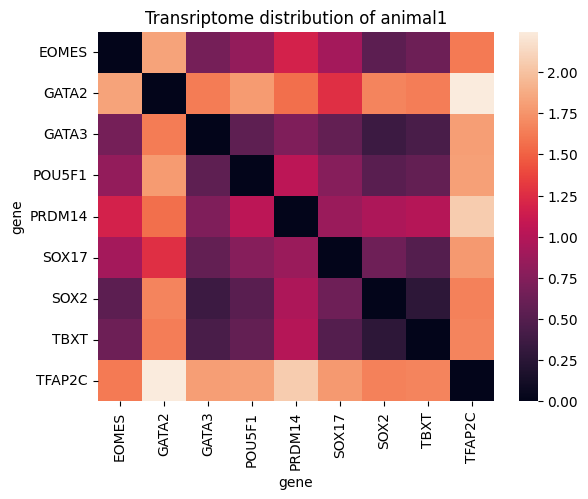

animal2 (9, 9)


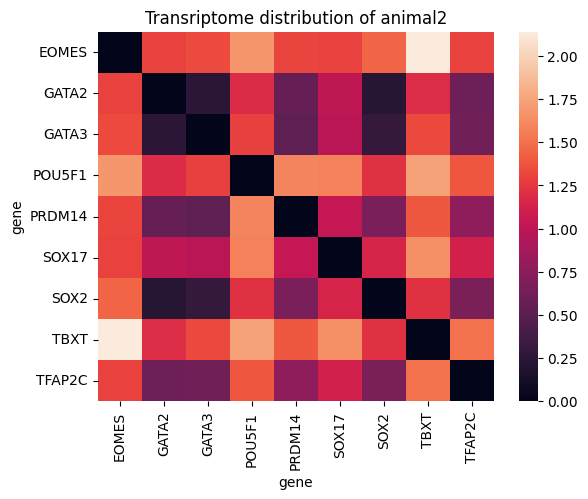

animal3 (9, 9)


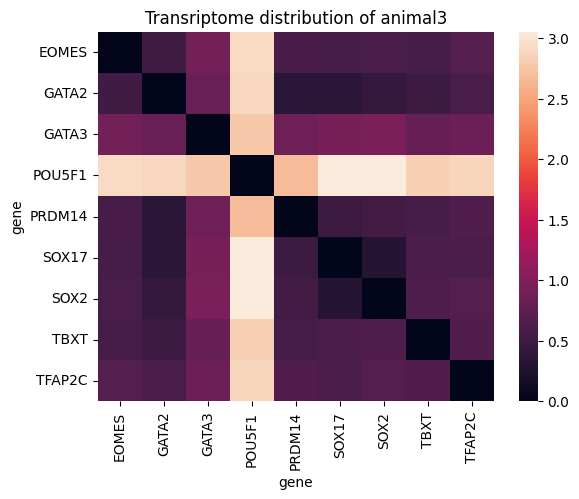

Check mean of gene distance matrices
animal1 1.0
animal2 1.0
animal3 1.0
Check variance of gene distance matrices
animal1 0.40442990488007785
animal2 0.30011913692762043
animal3 0.9318314137889337


In [15]:
spe_ot.check_gene_distance_matrix()

### Gromov-Wasserstein Optimal Transport
Calculate the optimal transport plan by solving the Entropy-regulalized GW problem

In [16]:
spe_ot = spe_ot.gromov_wasserstein_ot()

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Metal device set to: Apple M3 Max

systemMemory: 128.00 GB
maxCacheSize: 48.00 GB



W0000 00:00:1760618050.603898 2904671 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1760618050.614047 2904671 service.cc:145] XLA service 0x10d6424a0 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760618050.614056 2904671 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1760618050.615215 2904671 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1760618050.615230 2904671 mps_client.cc:384] XLA backend will use up to 103078739968 bytes on device 0 for SimpleAllocator.


epsilon = 0.0100000 converged


### Calculate normalized OTP (gene-to-gene correspondence rate)

In [17]:
spe_ot = spe_ot.normalize_otp()

### Transcriptomic discrepancy

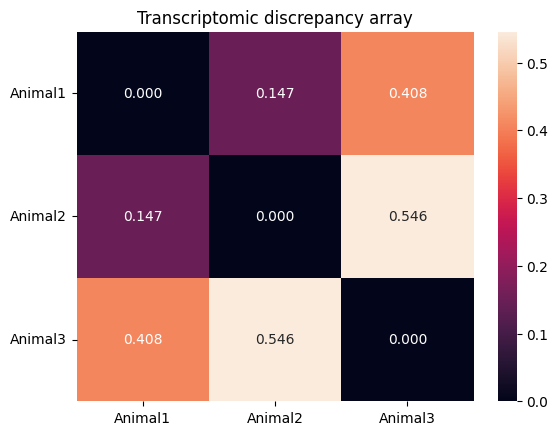

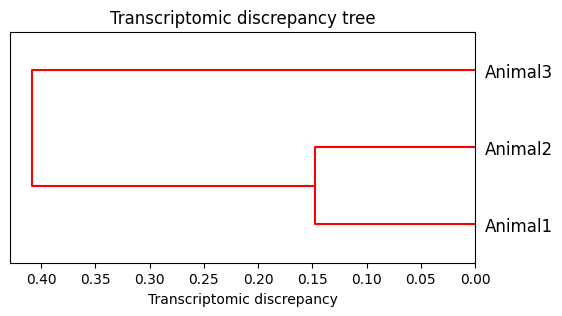

In [18]:
spe_ot.plot_transcriptomic_discrepancy()

### Gene-to-gene Corespondence

In [19]:
if spe_ot.data_option == "dataset1":
    target_genes = ["GATA3", "GATA2", "EOMES", "SOX17", "PRDM1", "TFAP2C"]
    target_species_pairs = "human_mouse"
    # target_species_pairs = "mouse_human"
elif spe_ot.data_option == "dataset2":
    target_genes = ["GATA3", "POU5F1", "SOX2"]
    target_species_pairs = "human_chimpanzee"
elif spe_ot.data_option == "custom":
    target_genes = ["GATA3", "GATA2", "EOMES"]
    target_species_pairs = "animal1_animal2"

top_n = 10

In [20]:
primate_gene_notation = ["all_capital_italic"] * len(spe_ot.species)
spe_gene_dict = dict(zip(spe_ot.species, primate_gene_notation))

# Reflects differences in genetic notation between primates and other species
if spe_ot.data_option == "dataset2":
    spe_gene_dict["mouse"] = "capitalized_italic"
elif spe_ot.data_option == "dataset1":
    spe_gene_dict["Ms"] = "capitalized_italic"

### Summarize results in Dashboard

In [21]:
spe_ot.dashboard(target_species_pairs, target_genes, top_n)

Animal1 -> Animal2: GATA3           Animal1 -> Animal2: GATA2           Animal1 -> Animal2: EOMES           
shape: (9, 3)                       shape: (9, 3)                       shape: (9, 3)                       
┌───────┬────────┬─────────┐        ┌───────┬────────┬──────────┐       ┌───────┬────────┬──────────┐       
│ index ┆ Gene   ┆ Value   │        │ index ┆ Gene   ┆ Value    │       │ index ┆ Gene   ┆ Value    │       
│ ---   ┆ ---    ┆ ---     │        │ ---   ┆ ---    ┆ ---      │       │ ---   ┆ ---    ┆ ---      │       
│ u32   ┆ str    ┆ str     │        │ u32   ┆ str    ┆ str      │       │ u32   ┆ str    ┆ str      │       
╞═══════╪════════╪═════════╡        ╞═══════╪════════╪══════════╡       ╞═══════╪════════╪══════════╡       
│ 1     ┆ SOX2   ┆ 49.3373 │        │ 1     ┆ EOMES  ┆ 100.0000 │       │ 1     ┆ SOX17  ┆ 100.0000 │       
│ 2     ┆ GATA2  ┆ 32.6457 │        │ 2     ┆ POU5F1 ┆ 0.0000   │       │ 2     ┆ PRDM14 ┆ 0.0000   │       
│ 3     ┆ GATA3  ┆ 

### Confirmation of expression levels of target genes and corresponding genes

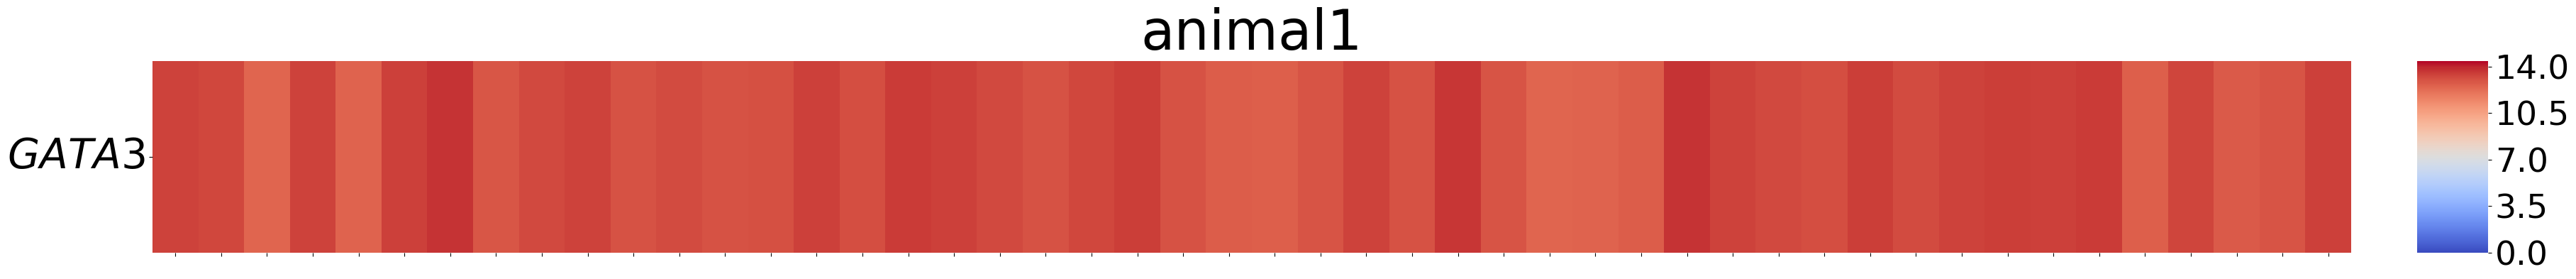

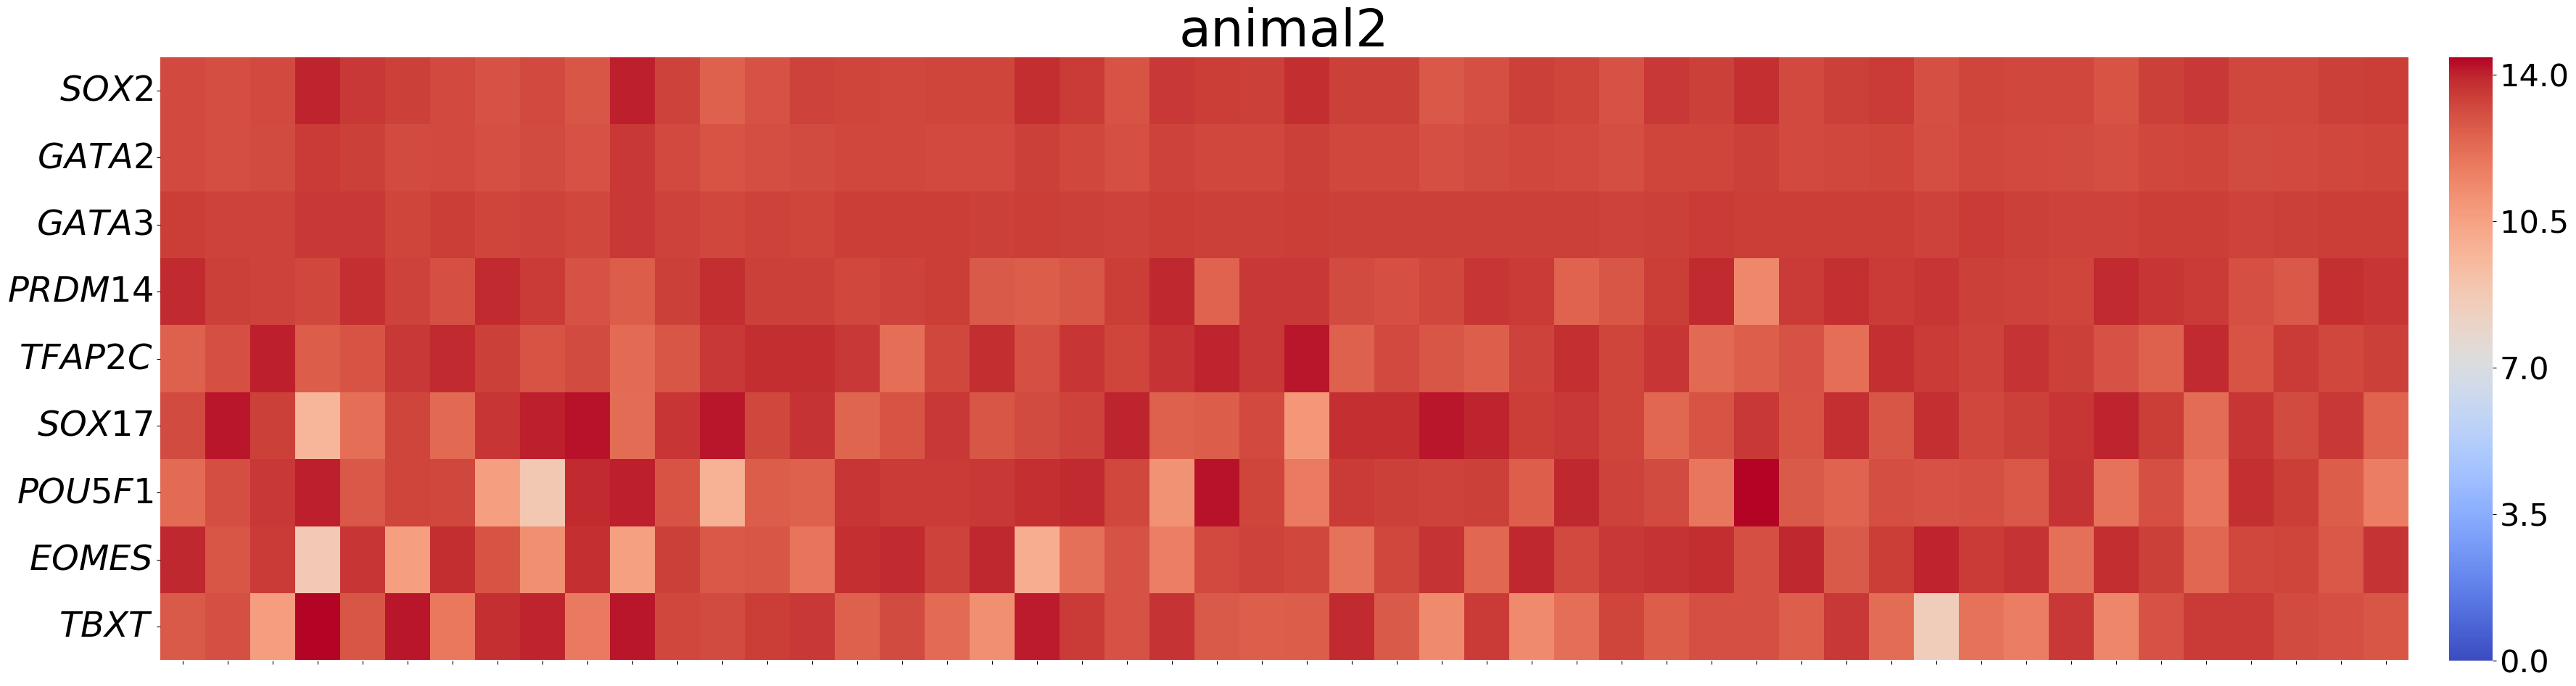

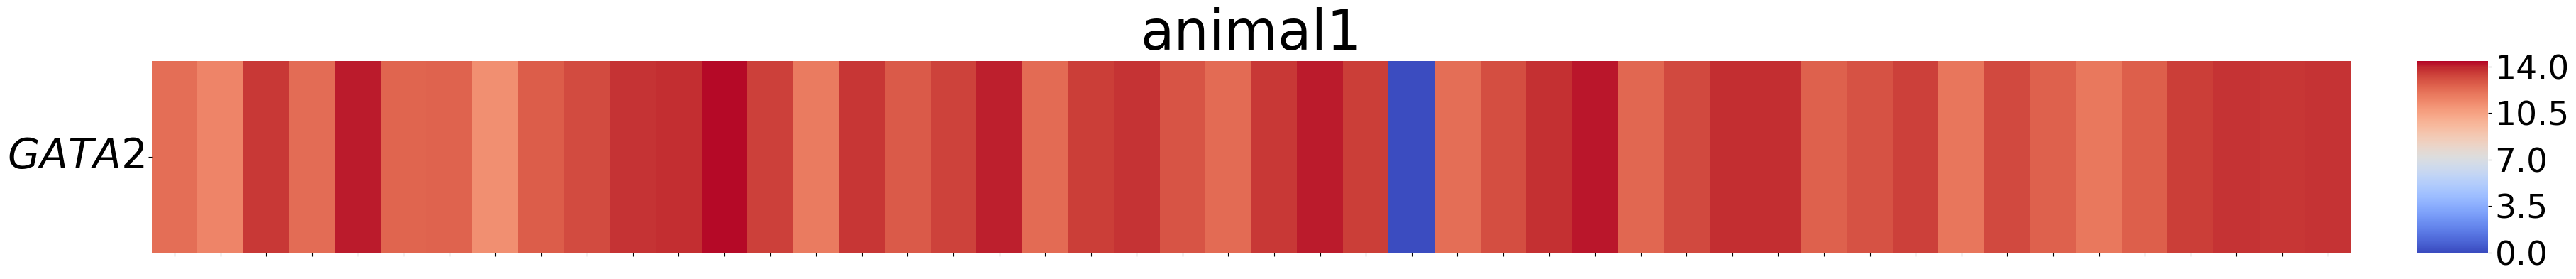

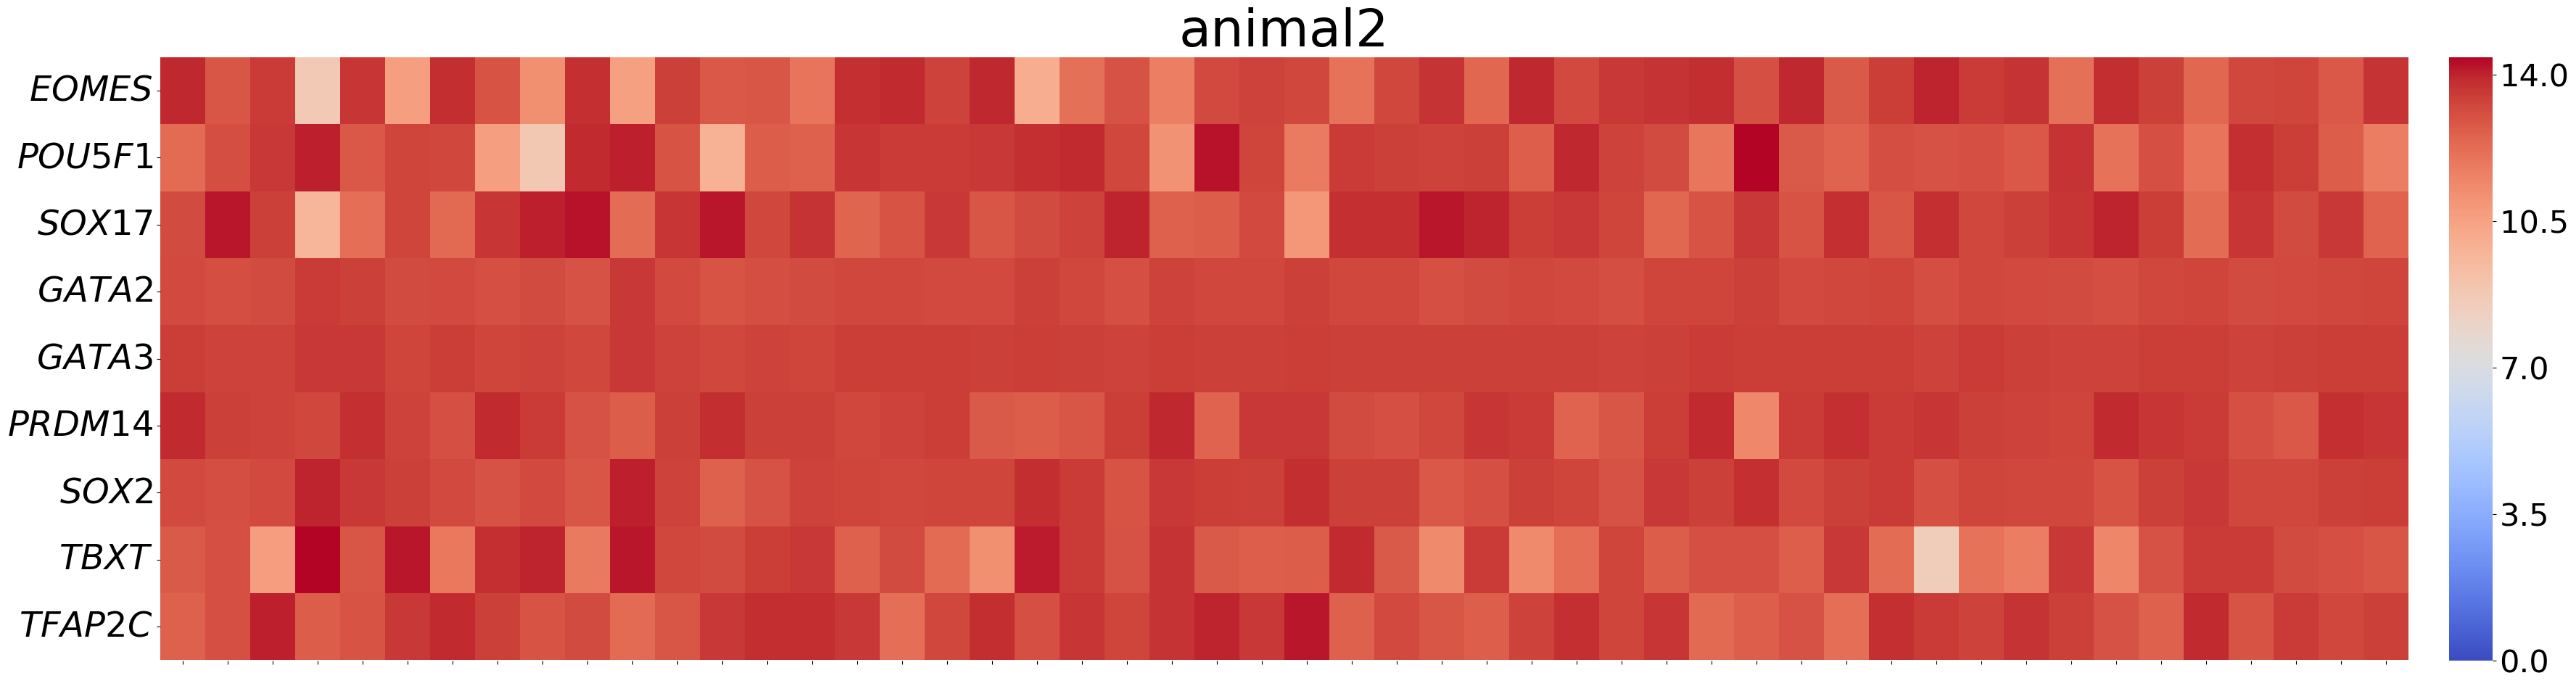

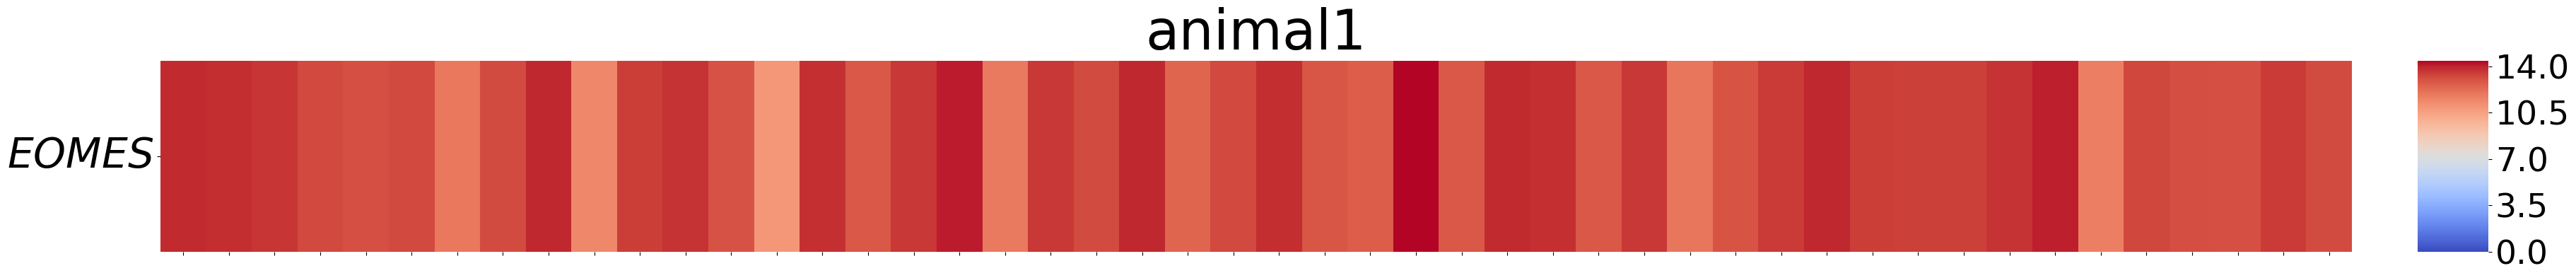

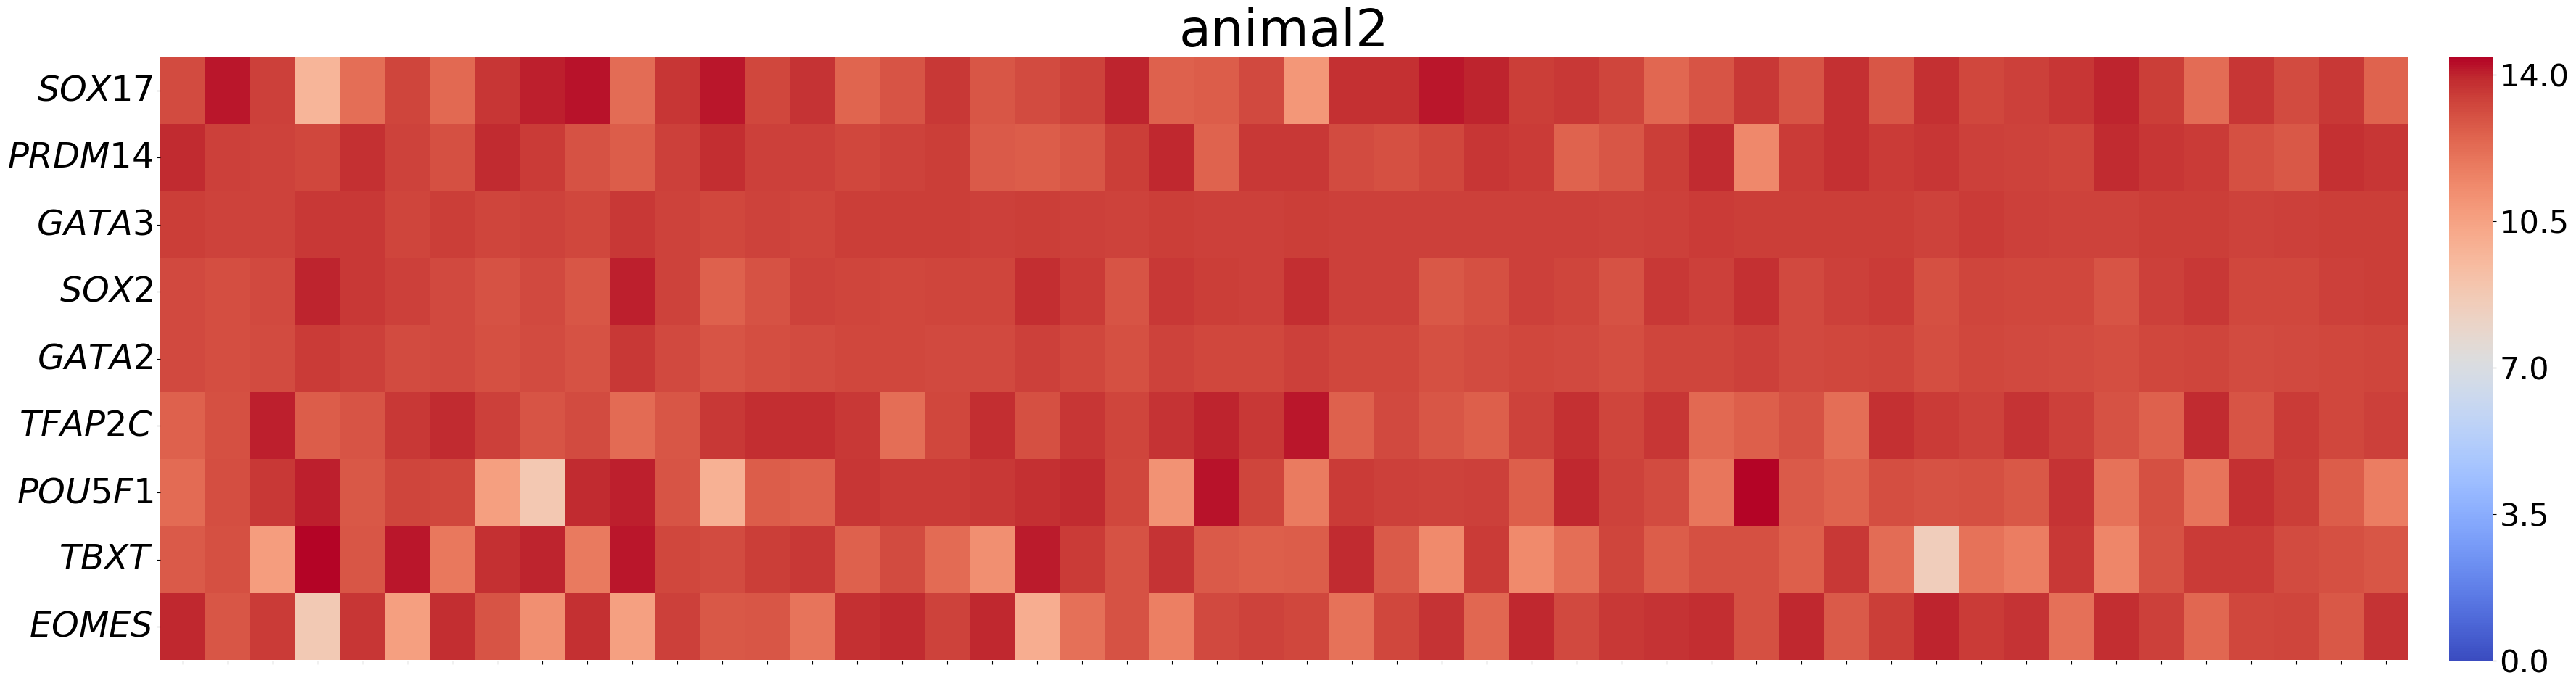

In [22]:
if spe_ot.data_option == "dataset1":
    spe_ot.corresponding_gene_expressions_separated_heatmap(target_species_pairs, spe_gene_dict, target_genes, top_n, fujiwara_opt=True)
else:
    spe_ot.corresponding_gene_expressions_separated_heatmap(target_species_pairs, spe_gene_dict, target_genes, top_n)

## Section 4. Visualization

### Check gene expression level

In [23]:
if data.data_option == "custom":
    spe = "animal1"
    thr = 12.1
    genes = ["POU5F1", "SOX2"]
elif data.data_option == "dataset2":
    spe = "mouse"
    thr = 4.5
    if spe == "human":
        genes = ["POU5F1", "SOX2"]
    else:
        genes = ["ZXDC", "ZZZ3"]
elif data.data_option == "dataset1":
    spe = "Hs"
    thr = 12.1
    genes = ["POU5F1", "SOX2"]

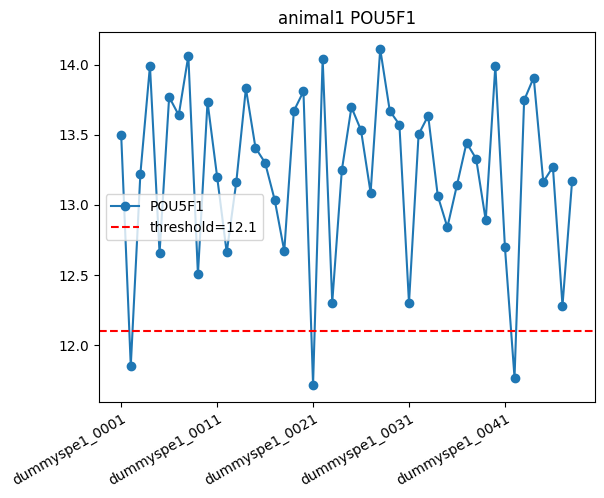

In [24]:
data.check_gene_exp(spe, genes[0], thr)

In [25]:
data.plot_read()

# Shape of Polars DataFrame with cell names added to the beginning of gene expression data
animal1 (48, 11)
animal2 (50, 11)
animal3 (49, 11)
animal1 Shape of the gene expression matrix (48, 10)
# Showing the first 5 rows (cells) and first 6 columns (genes) of the expression matrix for 'animal1'
gene               BLIMP1      EOMES      GATA2      GATA3     POU5F1  \
dummyspe1_0001  10.076089  13.911670  12.189479  13.351727  13.499112   
dummyspe1_0002  13.436575  13.848850  11.544985  13.286221  11.850287   
dummyspe1_0003  10.956706  13.661201  13.620851  12.499607  13.219348   
dummyspe1_0004  14.019885  13.204683  12.268121  13.397857  13.990831   
dummyspe1_0005  10.434193  13.057946  14.092186  12.509350  12.654813   

gene               PRDM14  
dummyspe1_0001  13.383226  
dummyspe1_0002  12.456498  
dummyspe1_0003  11.442472  
dummyspe1_0004  12.688756  
dummyspe1_0005  12.649078  
animal2 Shape of the gene expression matrix (50, 10)
# Showing the first 5 rows (cells) and firs

#### Plot the distribution of gene expression levels

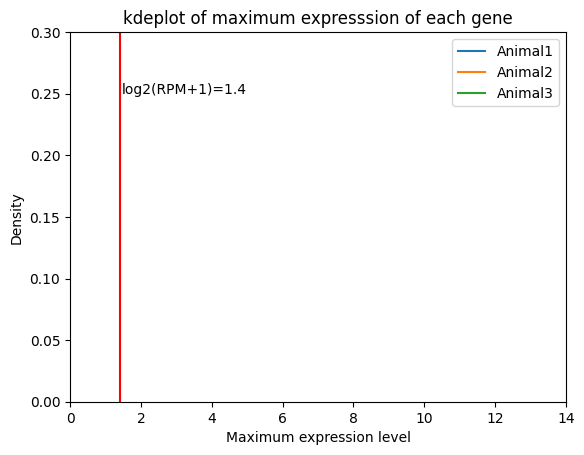

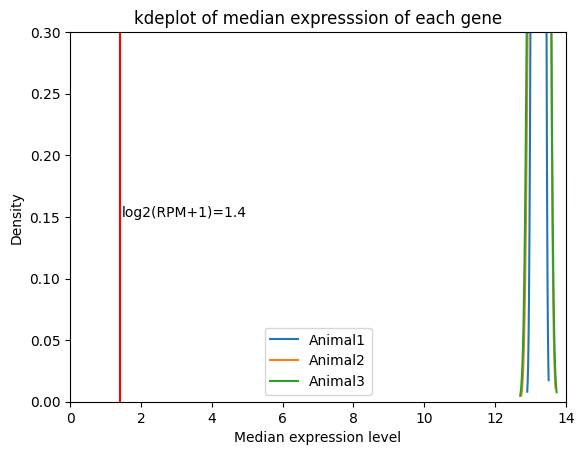

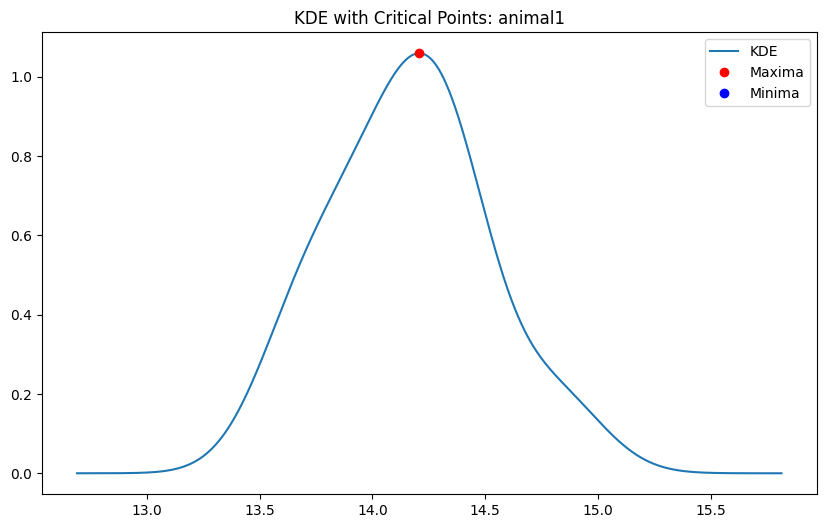

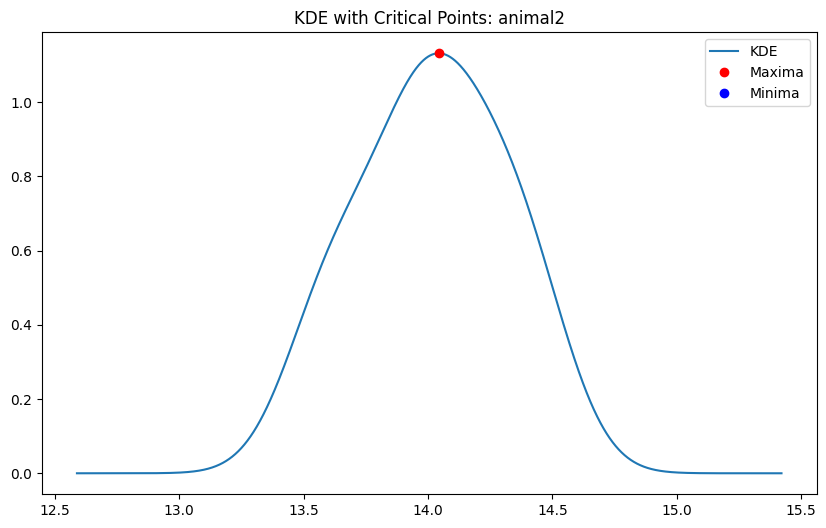

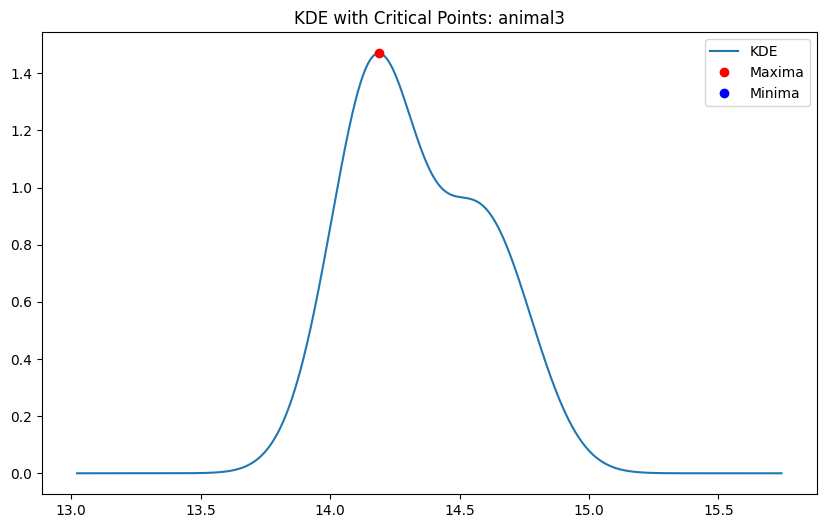

In [26]:
# spe_ot2 = SpeciesOT(data)
# spe_ot2.visualization()

spe_ot.visualization()

#### Check data size after preprocessing

Shape of adata after normalization and preprocessing
animal1 (48, 9)
animal2 (50, 9)
animal3 (49, 9)
# genes with all zero expression
animal1 0
animal2 0
animal3 0
custom
custom
custom


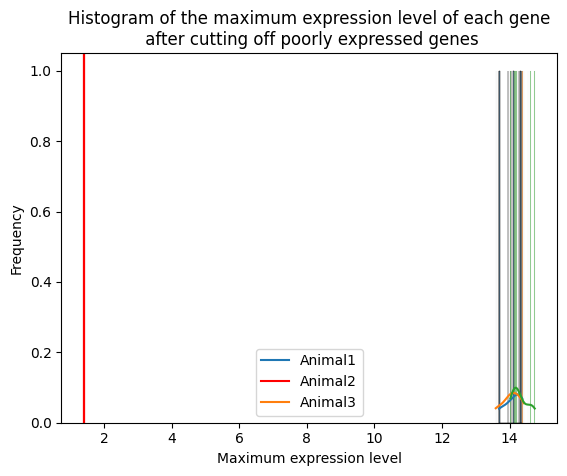

In [27]:
# spe_ot2 = SpeciesOT(data)
# spe_ot2.preprocessing(
# ).data_size_after_preprocessing()

spe_ot.data_size_after_preprocessing()

#### Plot which genes remained after preprocessing

In [28]:
labeled_genes = {}

for spe in spe_ot.species:
    labeled_genes[spe] = []
    
if spe_ot.data_option == "dataset1":
    labeled_genes["Ms"] = ["TBXT", "PRDM1", "PRDM14", "TFAP2C"]
    labeled_genes["Mf"] = ["GATA3", "GATA2", "EOMES", "SOX17", "TBXT",  "PRDM1", "PRDM14", "TFAP2C"]
    labeled_genes["Hs"] = ["GATA3", "GATA2", "EOMES", "SOX17", "PRDM1", "TFAP2C"]
elif spe_ot.data_option == "dataset2":
    for spe in spe_ot.species:
        labeled_genes[spe] = ["POU5F1", "SOX2", "NANOG"]

Explain Variance Ratio : [0.21484661 0.19019369]


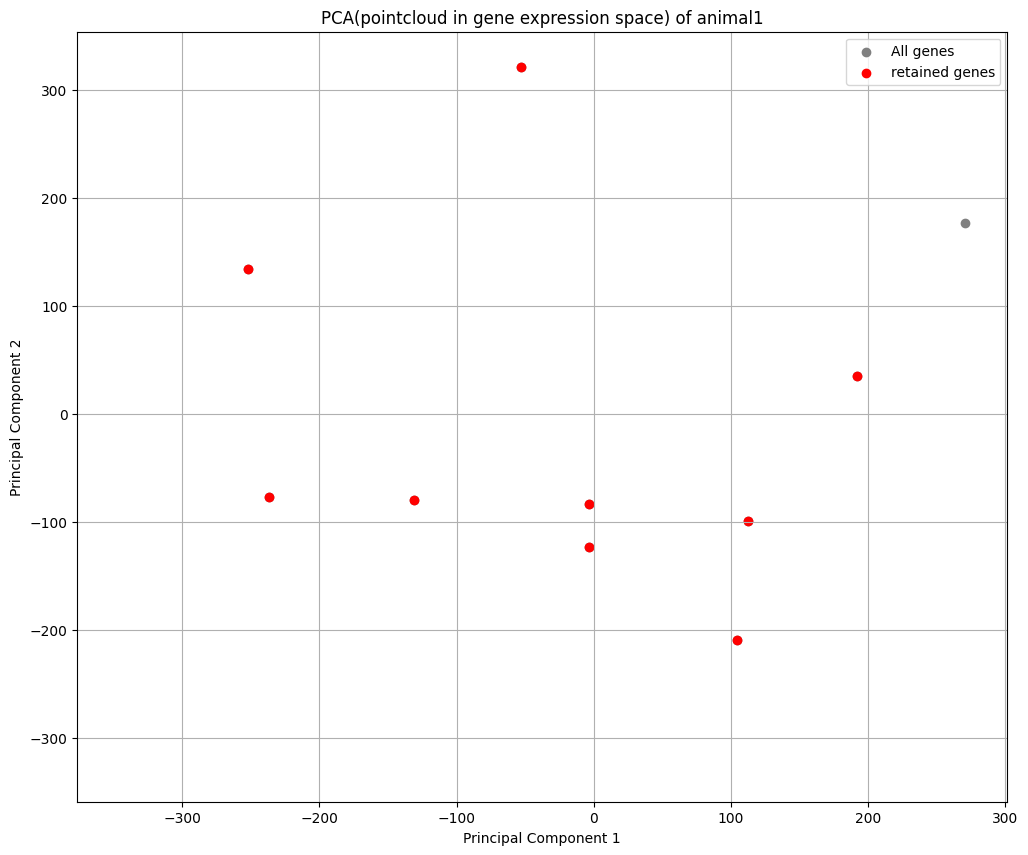

Explain Variance Ratio : [0.20453963 0.16413542]


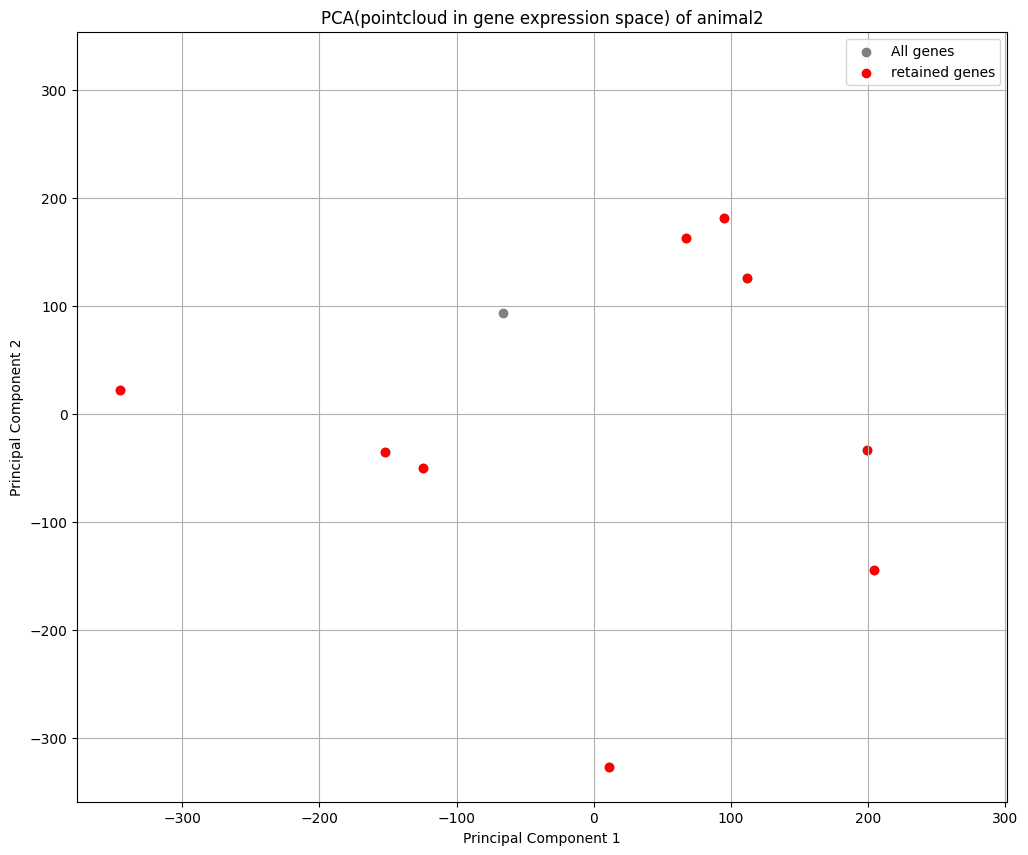

Explain Variance Ratio : [0.19539738 0.16940214]


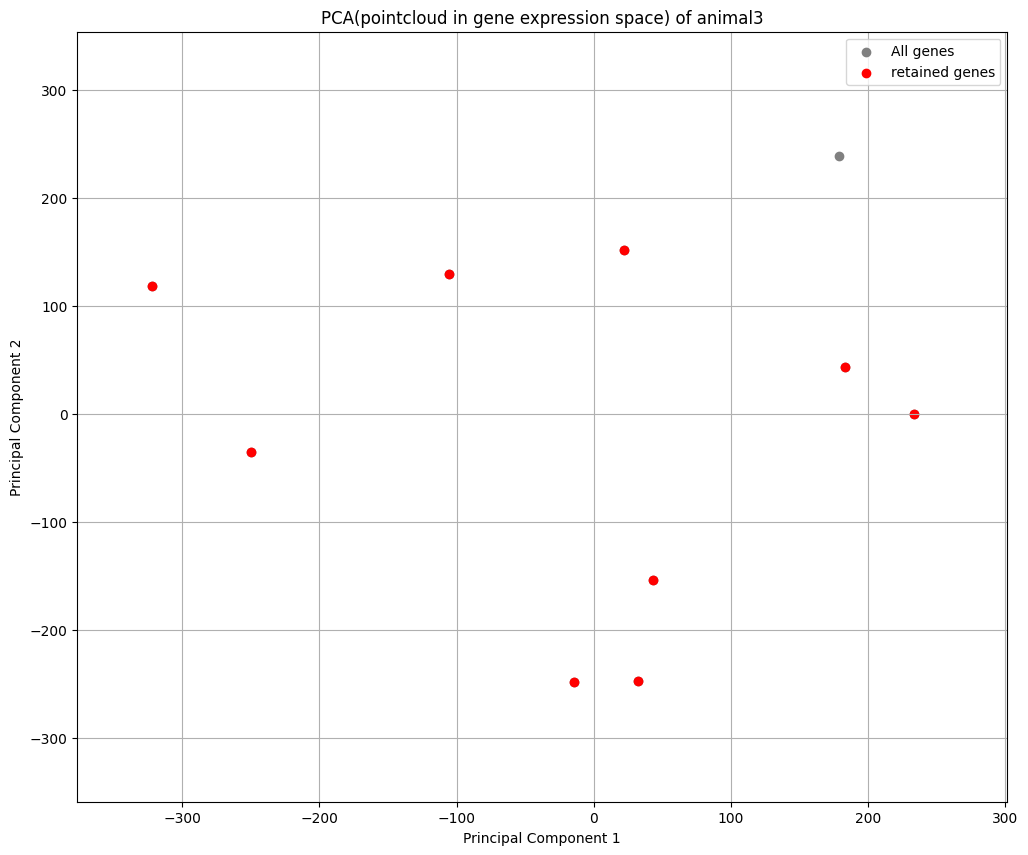

In [29]:
# spe_ot2 = SpeciesOT(data)
# spe_ot2.preprocessing(
# ).plot_pca_highlighting_genes_retained_after_preprocessing_plotly("all_gene", labeled_genes, spe_gene_dict)

spe_ot.plot_pca_highlighting_genes_retained_after_preprocessing("all_gene", labeled_genes, spe_gene_dict)

Visualization using Plotly is also possible (commented out for display purposes)

In [30]:
# spe_ot2 = SpeciesOT(data)
# spe_ot2.preprocessing(
# ).plot_pca_highlighting_genes_retained_after_preprocessing_plotly("all_gene", labeled_genes, spe_gene_dict)

# spe_ot.plot_pca_highlighting_genes_retained_after_preprocessing_plotly("all_gene", labeled_genes, spe_gene_dict)

#### Check calculated GW distance and OTP

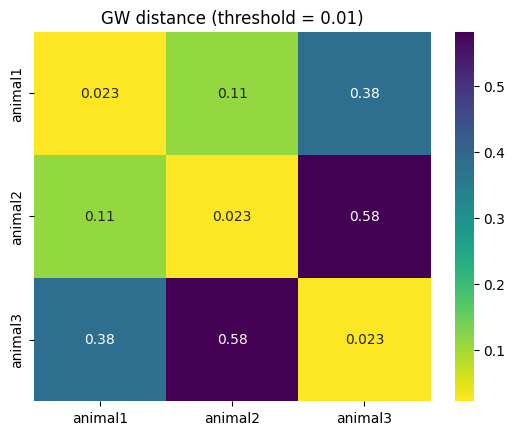

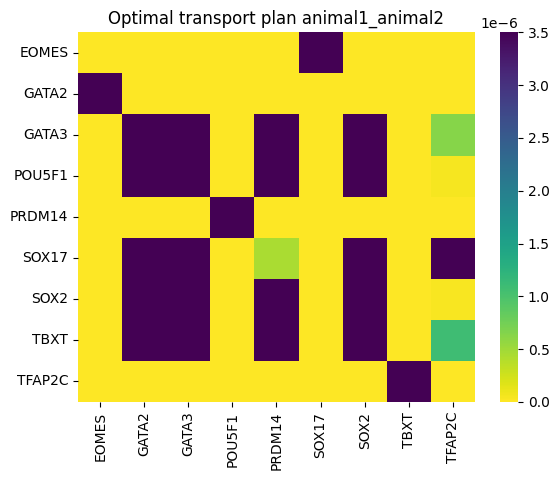

In [31]:
# spe_ot2 = SpeciesOT(data)
# spe_ot2.preprocessing(
# ).calculate_dismat(
# ).gromov_wasserstein_ot(
# ).check_optimal_transport_results()

spe_ot.check_optimal_transport_results()

#### Plot OTP after thresholding the top 5%

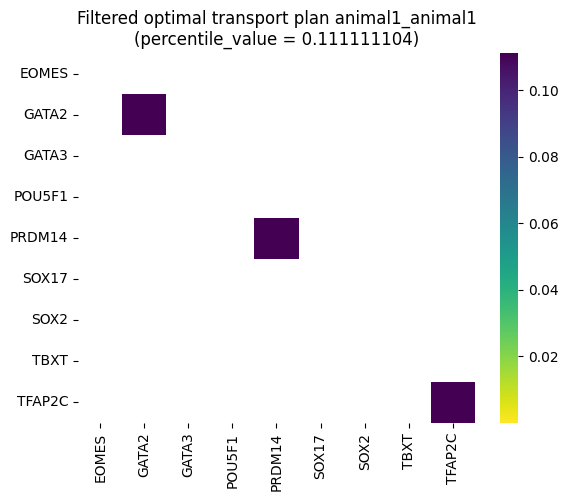

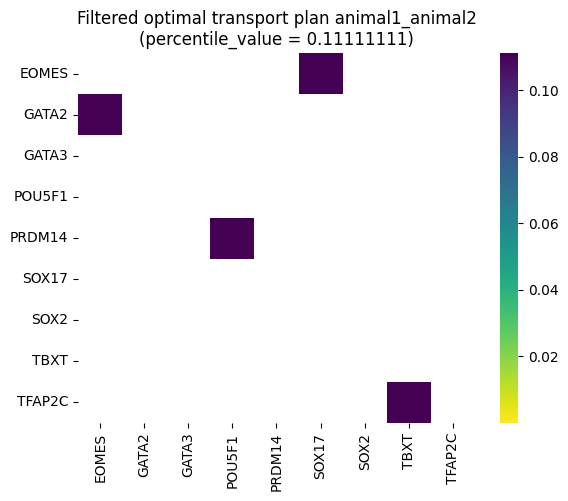

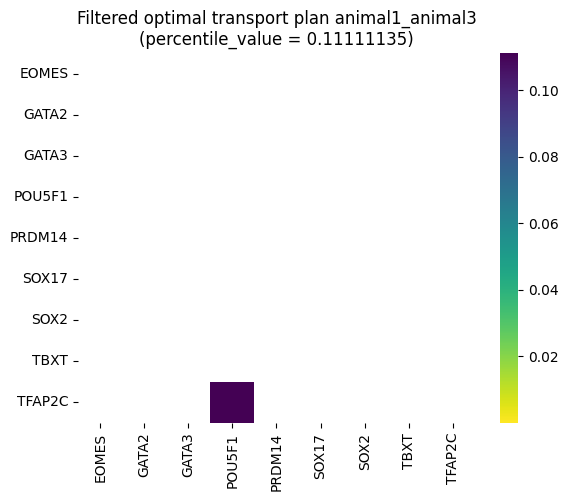

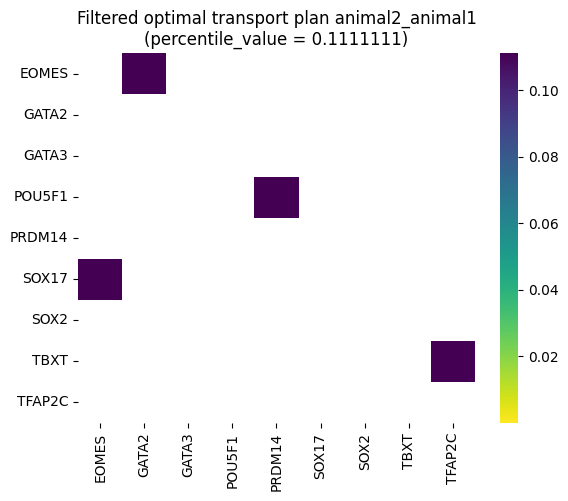

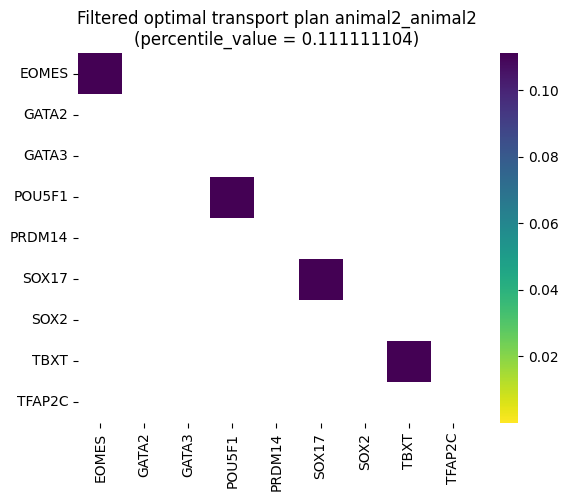

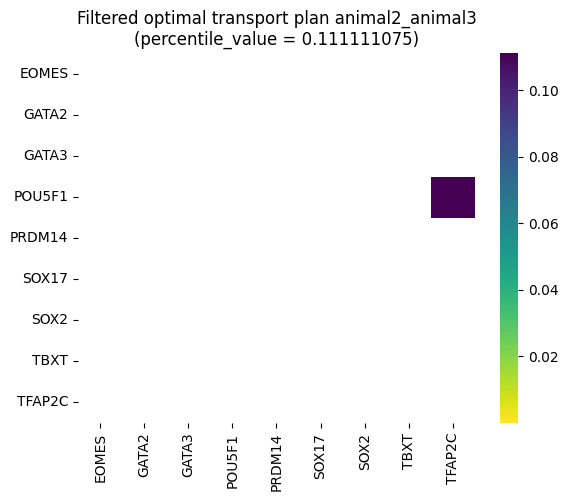

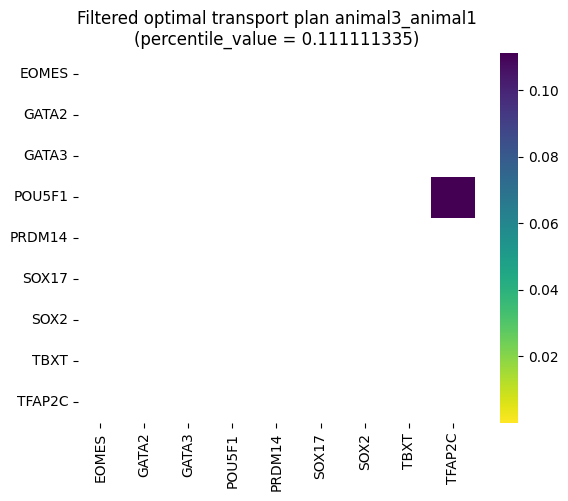

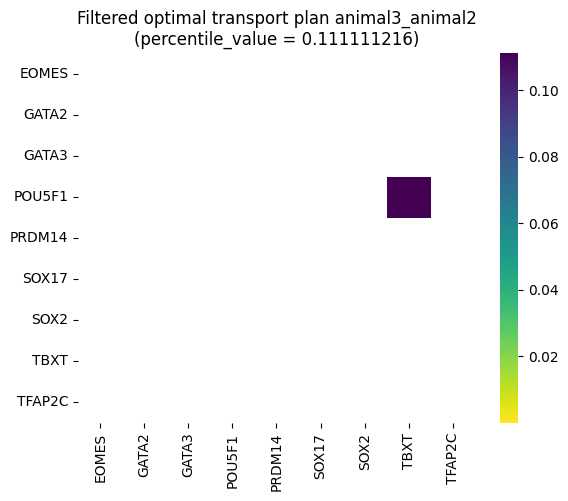

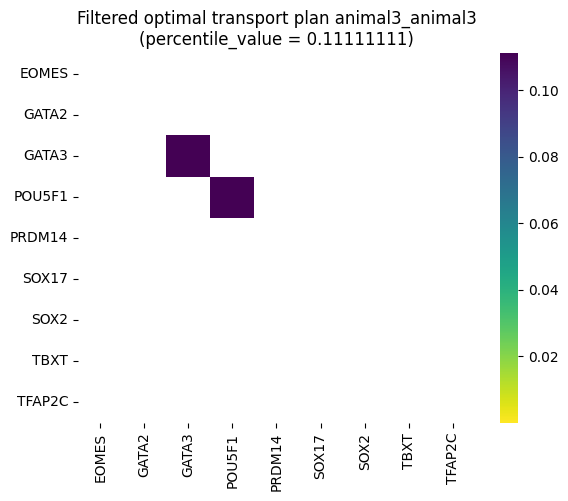

In [32]:
# spe_ot = SpeciesOT(Data)
# spe_ot.preprocessing(
# ).calculate_dismat(
# ).gromov_wasserstein_ot(
# ).filter_otp()

spe_ot.filter_otp()

#### Creat heatmap of common genes between species

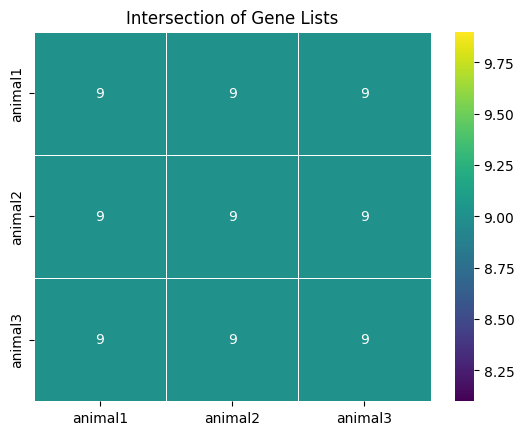

In [33]:
# spe_ot2 = SpeciesOT(Data)
# spe_ot2.preprocessing(
# ).calculate_dismat(
# ).gromov_wasserstein_ot(
# ).intersection_of_gene_lists()

spe_ot.intersection_of_gene_lists()

#### Check the distribution of the values of the normalized OTP

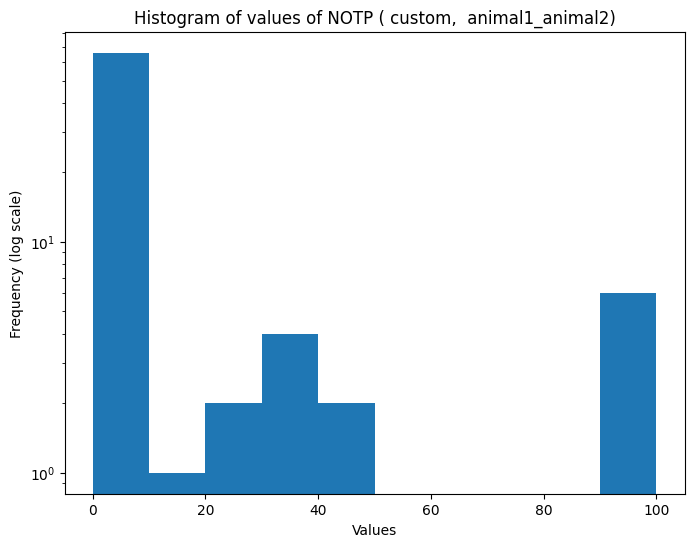

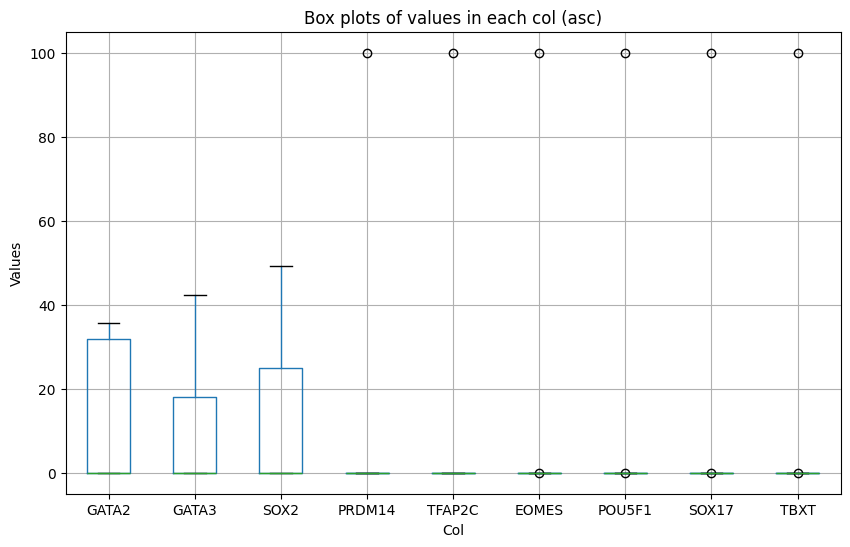

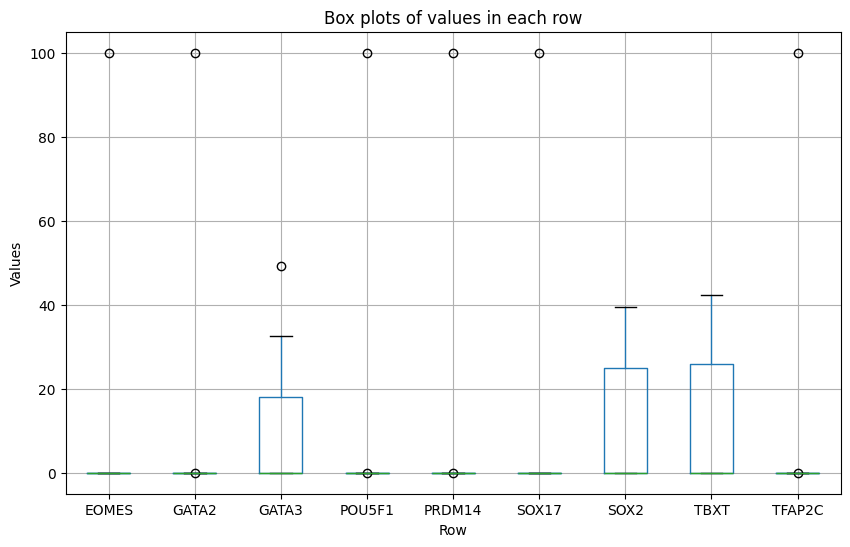

In [34]:
# spe_ot2 = SpeciesOT(data)
# spe_ot2.preprocessing(
# ).calculate_dismat(
# ).gromov_wasserstein_ot(
# ).normalize_otp(
# ).distribution_of_values()

spe_ot.distribution_of_values()

## Section 5. Chained Processing

In [35]:
data2 = Data(config).read_csv().normalization().read_tf()


animal1 (48, 10)
animal2 (50, 10)
animal3 (49, 10)
# data size after noise reduction and normalization
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(10), '#non-significant genes': np.int64(0), '#silent genes': np.int64(0), 'ell': np.int64(9), 'Elapsed time': '0h 0m 0s 001ms', 'solver': 'full'}
animal1 (48, 10)
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(10), '#non-significant genes': np.int64(0), '#silent genes': np.int64(0), 'ell': np.int64(9), 'Elapsed time': '0h 0m 0s 000ms', 'solver': 'full'}
animal2 (50, 10)
start RECODE for scRNA-seq data
end RECODE for scRNA-seq
log: {'seq_target': 'RNA', '#significant genes': np.int64(10), '#non-significant genes': np.int64(0), '#silent genes': np.int64(0), 'ell': np.int64(9), 'Elapsed time': '0h 0m 0s 000ms', 'solver': 'full'}
animal3 (49, 10)
# Number of genes
(1639,)


In [39]:
spe_ot2 = SpeciesOT(data2).preprocessing(
).calculate_gene_distance_matrix(
).gromov_wasserstein_ot(
).normalize_otp(
).dashboard(
    target_species_pairs="animal1_animal2", 
    target_genes=["GATA3", "GATA2", "EOMES"], 
    top_n=10
    )

No minima found.
No minima found.
No minima found.
first_min_x[animal1] is None
first_min_x[animal2] is None
first_min_x[animal3] is None
# Shape of gene expression data before masking
animal1 (48, 9)
animal2 (50, 9)
animal3 (49, 9)
# Shape of adata after removing columns (gene) where even the maximum value is below the threshold
animal1 (48, 9)
animal2 (50, 9)
animal3 (49, 9)
# Number of genes for which the maximum expression value is greater than a threshold value
animal1 (9,)
animal2 (9,)
animal3 (9,)
epsilon = 0.0100000 converged
Animal1 -> Animal2: GATA3           Animal1 -> Animal2: GATA2           Animal1 -> Animal2: EOMES           
shape: (9, 3)                       shape: (9, 3)                       shape: (9, 3)                       
┌───────┬────────┬─────────┐        ┌───────┬────────┬──────────┐       ┌───────┬────────┬──────────┐       
│ index ┆ Gene   ┆ Value   │        │ index ┆ Gene   ┆ Value    │       │ index ┆ Gene   ┆ Value    │       
│ ---   ┆ ---    ┆ ---  

## End